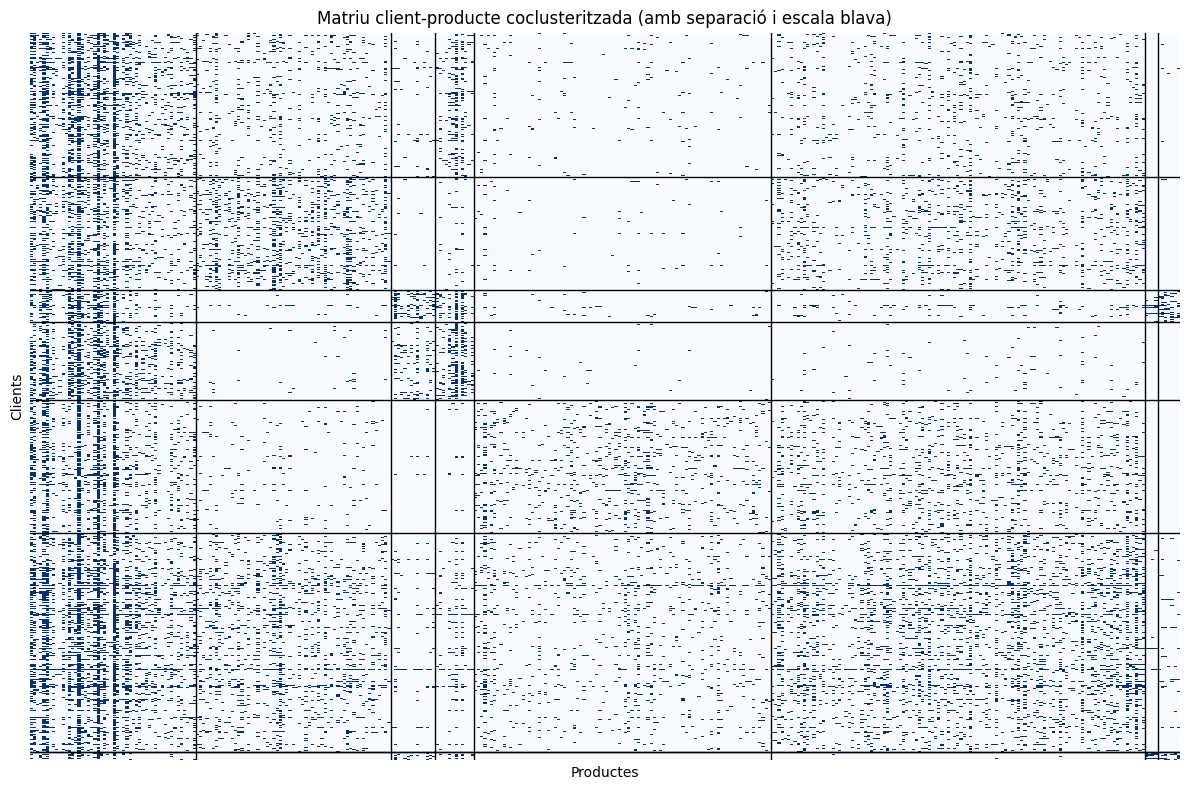

In [1]:
import pandas as pd
from sklearn.cluster import SpectralCoclustering
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Carregar dades
df = pd.read_csv("../data/df_preparat.csv")

# 2. Crear matriu client × producte (binària)
client_product_matrix = pd.crosstab(df["CustomerID"], df["Product_Description"])
client_product_matrix = (client_product_matrix > 0).astype(int)

# 3. Filtrar clients i productes amb activitat mínima
min_client_purchases = 5
min_product_purchases = 10

filtered_matrix = client_product_matrix.loc[
    client_product_matrix.sum(axis=1) >= min_client_purchases,
    client_product_matrix.sum(axis=0) >= min_product_purchases
]

# 4. Aplicar coclustering
n_clusters = 8
model = SpectralCoclustering(n_clusters=n_clusters, random_state=0)
model.fit(filtered_matrix)

# 5. Afegir etiquetes de coclústers
filtered_matrix["Client_Cluster"] = model.row_labels_
product_clusters = pd.DataFrame({
    "Product_Description": filtered_matrix.columns[:-1],  # última és Client_Cluster
    "Product_Cluster": model.column_labels_
})

# 6. Exportar coclústers
filtered_matrix.reset_index().to_csv("client_coclusters.csv", index=False)
product_clusters.to_csv("product_coclusters.csv", index=False)

# 7. Reordenar matriu
reordered_matrix = filtered_matrix.drop("Client_Cluster", axis=1).iloc[
    model.row_labels_.argsort(), 
    model.column_labels_.argsort()
]

# 8. Visualització millorada: escala blava + línies de separació
row_ticks = np.cumsum(np.bincount(model.row_labels_))[:-1]
col_ticks = np.cumsum(np.bincount(model.column_labels_))[:-1]

plt.figure(figsize=(12, 8))
ax = sns.heatmap(reordered_matrix, cmap="Blues", cbar=False, xticklabels=False, yticklabels=False)

# Línies negres que separen coclústers
for r in row_ticks:
    ax.axhline(r, color='black', lw=1)
for c in col_ticks:
    ax.axvline(c, color='black', lw=1)

plt.title("Matriu client-producte coclusteritzada (amb separació i escala blava)")
plt.xlabel("Productes")
plt.ylabel("Clients")
plt.tight_layout()
plt.show()



In [2]:
# Llistes útils
product_columns = [col for col in filtered_matrix.columns if col != "Client_Cluster"]

# Iterem per cada clúster de clients
for client_cluster_id in range(n_clusters):
    clients_idx = filtered_matrix.index[model.row_labels_ == client_cluster_id]

    # Calcular densitat per cada product_cluster
    cluster_densities = []

    for j in range(n_clusters):
        products_idx = [col for k, col in enumerate(product_columns) if model.column_labels_[k] == j]
        block = filtered_matrix.loc[clients_idx, products_idx]
        if block.size == 0:
            continue
        density = block.values.sum() / block.size
        cluster_densities.append({
            "Product_Cluster": j,
            "Density": round(density, 4),
            "Num_Clients": len(clients_idx),
            "Num_Products": len(products_idx)
        })

    # Convertim a DataFrame i apliquem criteri de densitat destacada
    density_df = pd.DataFrame(cluster_densities)
    mean_density = density_df["Density"].mean()
    std_density = density_df["Density"].std()
    threshold = mean_density + 0.5 * std_density

    # Seleccionem product_clusters rellevants per aquest grup de clients
    top_clusters = density_df[density_df["Density"] >= threshold]["Product_Cluster"].tolist()

    # Extreure productes dels clústers seleccionats
    products_selected = [
        col for i, col in enumerate(product_columns)
        if model.column_labels_[i] in top_clusters
    ]

    # Guardar resultats si hi ha productes
    if products_selected:
        product_df = pd.DataFrame({"Product_Description": products_selected})
        product_df.to_csv(f"products_relevant_for_client_cluster_{client_cluster_id}.csv", index=False)
        print(f"✅ Client cluster {client_cluster_id} → product clusters {top_clusters} → {len(products_selected)} productes exportats.")
    else:
        print(f"ℹ️ Client cluster {client_cluster_id} → cap product cluster supera el llindar.")


✅ Client cluster 0 → product clusters [0, 3] → 64 productes exportats.
✅ Client cluster 1 → product clusters [0, 1] → 113 productes exportats.
✅ Client cluster 2 → product clusters [0, 2, 3, 7] → 85 productes exportats.
✅ Client cluster 3 → product clusters [0, 3] → 64 productes exportats.
✅ Client cluster 4 → product clusters [0, 5] → 169 productes exportats.
✅ Client cluster 5 → product clusters [0, 5] → 169 productes exportats.
✅ Client cluster 6 → product clusters [6] → 4 productes exportats.
✅ Client cluster 7 → product clusters [6] → 4 productes exportats.


In [3]:
# Codi per calcular productes rellevants excloent el clúster 0 de productes

excluded_product_cluster = 0  # el que vols ignorar

product_columns = [col for col in filtered_matrix.columns if col != "Client_Cluster"]

for client_cluster_id in range(n_clusters):
    clients_idx = filtered_matrix.index[model.row_labels_ == client_cluster_id]

    cluster_densities = []

    for j in range(n_clusters):
        if j == excluded_product_cluster:
            continue  # Saltem el clúster generalista

        products_idx = [col for k, col in enumerate(product_columns) if model.column_labels_[k] == j]
        block = filtered_matrix.loc[clients_idx, products_idx]
        if block.size == 0:
            continue
        density = block.values.sum() / block.size
        cluster_densities.append({
            "Product_Cluster": j,
            "Density": round(density, 4),
            "Num_Clients": len(clients_idx),
            "Num_Products": len(products_idx)
        })

    if not cluster_densities:
        print(f"ℹ️ Client cluster {client_cluster_id} → no hi ha cap product cluster útil (exclòs el 0).")
        continue

    density_df = pd.DataFrame(cluster_densities)
    mean_density = density_df["Density"].mean()
    std_density = density_df["Density"].std()
    threshold = mean_density + 0.5 * std_density

    top_clusters = density_df[density_df["Density"] >= threshold]["Product_Cluster"].tolist()

    products_selected = [
        col for i, col in enumerate(product_columns)
        if model.column_labels_[i] in top_clusters
    ]

    if products_selected:
        product_df = pd.DataFrame({"Product_Description": products_selected})
        product_df.to_csv(f"products_relevant_for_client_cluster_{client_cluster_id}_NO_CLUSTER0.csv", index=False)
        print(f"✅ [Sense cluster 0] Client cluster {client_cluster_id} → clusters {top_clusters} → {len(products_selected)} productes exportats.")
    else:
        print(f"ℹ️ [Sense cluster 0] Client cluster {client_cluster_id} → cap clúster supera el llindar.")


✅ [Sense cluster 0] Client cluster 0 → clusters [1, 3] → 73 productes exportats.
✅ [Sense cluster 0] Client cluster 1 → clusters [1, 5] → 178 productes exportats.
✅ [Sense cluster 0] Client cluster 2 → clusters [2, 3, 7] → 33 productes exportats.
✅ [Sense cluster 0] Client cluster 3 → clusters [3] → 12 productes exportats.
✅ [Sense cluster 0] Client cluster 4 → clusters [4, 5] → 210 productes exportats.
✅ [Sense cluster 0] Client cluster 5 → clusters [1, 5] → 178 productes exportats.
✅ [Sense cluster 0] Client cluster 6 → clusters [6] → 4 productes exportats.
✅ [Sense cluster 0] Client cluster 7 → clusters [6] → 4 productes exportats.


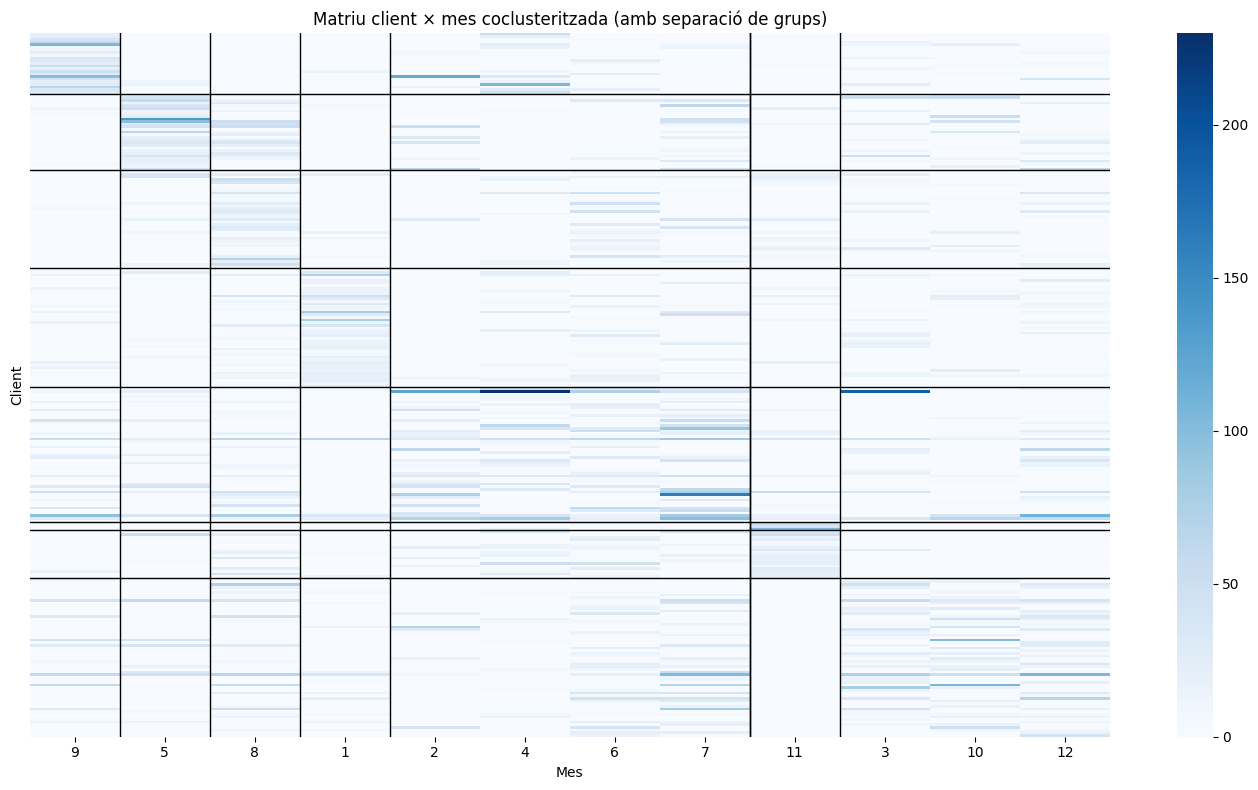

In [4]:
import pandas as pd
from sklearn.cluster import SpectralCoclustering
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Carregar les dades
df = pd.read_csv("../data/df_preparat.csv")

# 2. Conversió i neteja
df["Month"] = pd.to_numeric(df["Month"], errors="coerce")
df = df.dropna(subset=["Month", "CustomerID"])

# 3. Crear matriu client × mes
client_month_matrix = pd.crosstab(df["CustomerID"], df["Month"])

# 4. Filtrar dades poc significatives
filtered_client_month = client_month_matrix.loc[
    client_month_matrix.gt(0).sum(axis=1) >= 3,
    client_month_matrix.gt(0).sum(axis=0) >= 5
]

# 5. Coclústers amb més grups
n_clusters = 8
model_cm = SpectralCoclustering(n_clusters=n_clusters, random_state=0)
model_cm.fit(filtered_client_month)

# 6. Afegim els coclústers
filtered_client_month["Client_Cluster"] = model_cm.row_labels_
month_clusters_cm = pd.DataFrame({
    "Month": filtered_client_month.columns[:-1],
    "Month_Cluster": model_cm.column_labels_
})

# 7. Exportació
filtered_client_month.reset_index().to_csv("client_month_coclusters.csv", index=False)
month_clusters_cm.to_csv("month_coclusters_client_view.csv", index=False)

# 8. Visualització millorada
# Reordenem
reordered_matrix = filtered_client_month.drop("Client_Cluster", axis=1).iloc[
    model_cm.row_labels_.argsort(),
    model_cm.column_labels_.argsort()
]

# Divisions per coclústers (línies de separació)
row_ticks = np.cumsum(np.bincount(model_cm.row_labels_))[:-1]
col_ticks = np.cumsum(np.bincount(model_cm.column_labels_))[:-1]

# Plot
plt.figure(figsize=(14, 8))
ax = sns.heatmap(reordered_matrix, cmap="Blues", cbar=True, xticklabels=True, yticklabels=False)
for r in row_ticks:
    ax.axhline(r, color='black', lw=1)
for c in col_ticks:
    ax.axvline(c, color='black', lw=1)
plt.title("Matriu client × mes coclusteritzada (amb separació de grups)")
plt.xlabel("Mes")
plt.ylabel("Client")
plt.tight_layout()
plt.show()


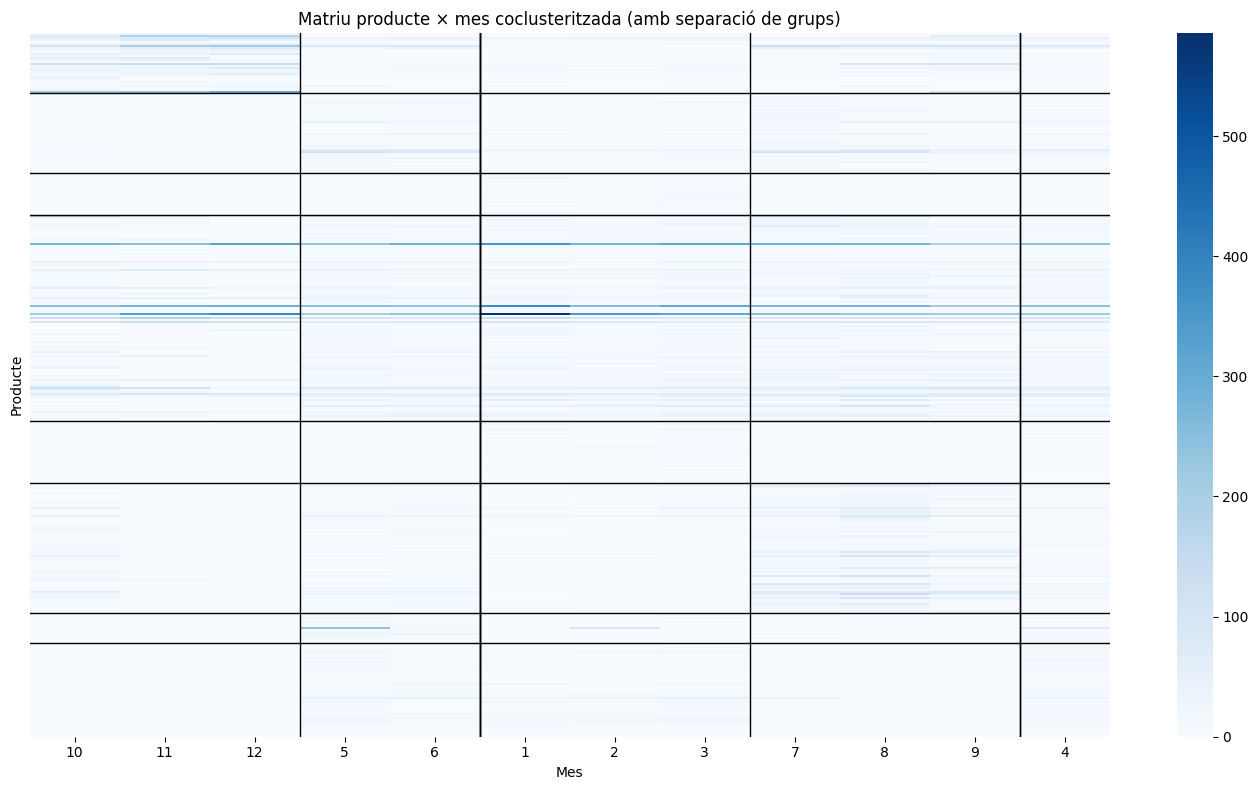

In [6]:
import pandas as pd
from sklearn.cluster import SpectralCoclustering
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Carregar les dades
df = pd.read_csv("../data/df_preparat.csv")

# 2. Conversió i neteja
df["Month"] = pd.to_numeric(df["Month"], errors="coerce")
df = df.dropna(subset=["Month", "Product_Description"])

# 3. Crear matriu client × mes
client_month_matrix = pd.crosstab(df["Product_Description"], df["Month"])

# 4. Filtrar dades poc significatives
filtered_client_month = client_month_matrix.loc[
    client_month_matrix.gt(0).sum(axis=1) >= 3,
    client_month_matrix.gt(0).sum(axis=0) >= 5
]

# 5. Coclústers amb més grups
n_clusters = 8
model_cm = SpectralCoclustering(n_clusters=n_clusters, random_state=0)
model_cm.fit(filtered_client_month)

# 6. Afegim els coclústers
filtered_client_month["Product_Cluster"] = model_cm.row_labels_
month_clusters_cm = pd.DataFrame({
    "Month": filtered_client_month.columns[:-1],
    "Month_Cluster": model_cm.column_labels_
})

# 7. Exportació
filtered_client_month.reset_index().to_csv("product_month_coclusters.csv", index=False)
month_clusters_cm.to_csv("month_coclusters_product_view.csv", index=False)

# 8. Visualització millorada
# Reordenem
reordered_matrix = filtered_client_month.drop("Product_Cluster", axis=1).iloc[
    model_cm.row_labels_.argsort(),
    model_cm.column_labels_.argsort()
]

# Divisions per coclústers (línies de separació)
row_ticks = np.cumsum(np.bincount(model_cm.row_labels_))[:-1]
col_ticks = np.cumsum(np.bincount(model_cm.column_labels_))[:-1]

# Plot
plt.figure(figsize=(14, 8))
ax = sns.heatmap(reordered_matrix, cmap="Blues", cbar=True, xticklabels=True, yticklabels=False)
for r in row_ticks:
    ax.axhline(r, color='black', lw=1)
for c in col_ticks:
    ax.axvline(c, color='black', lw=1)
plt.title("Matriu producte × mes coclusteritzada (amb separació de grups)")
plt.xlabel("Mes")
plt.ylabel("Producte")
plt.tight_layout()
plt.show()
